# Quiz 0

Both **regression** and **classification** tasks are a form of predictive modeling approach to characterize the relationship between observational input data and a desired response (or target). In other words, they are both **supervised learning** tasks. In classification, the target is categorical, whereas in regression, the target is continuous.

Examples of classification tasks:
* Handwritten character classification
* Speech emotion classification

Examples of regression tasks:
* Car detection in an image
* Mortgage rate prediction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

In [2]:
X = np.load('dataset.npy')

X.shape

(3000, 3)

The dataset is a matrix of size $3000\times 3$.

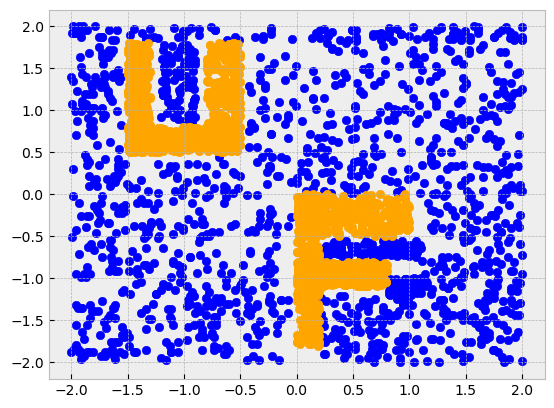

In [3]:
plt.scatter(X[X[:,2]==0,0],X[X[:,2]==0,1], c='blue')
plt.scatter(X[X[:,2]==1,0],X[X[:,2]==1,1], c='orange');

# several color-coding will be accepted for full credit

The dataset represents a UF mask.

In [4]:
import scipy.stats as stats

Under this RV, probability that observed sample is >15 is 0.23750777887760147


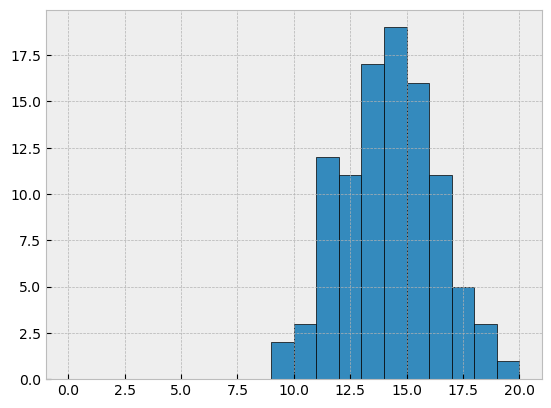

In [5]:
# Binomial RV with parameters N=20, p=0.7
X = stats.binom(20,0.7)

# Draw 100 samples at random from this RV
sample = X.rvs(size=100)

# Plot the histogram
plt.hist(sample, bins=range(0,21), edgecolor='k');

# Under this RV, probability that observed sample is >=15 is
print('Under this RV, probability that observed sample is >15 is', X.sf(15))

# Course Policies

Please read the course [syllabus](https://ufl.instructure.com/courses/514421/assignments/syllabus) for a full description of course policies.

# Prerequisites Mini-Test

1. **Answer the following questions:**
   1. **Consider the function, $f(x)=\frac{1}{2}(g(x))^4$, where $g(x)=2x+1$. Use the chain rule to compute the derivative $\frac{\partial f}{\partial x}$. Show your work (you may include a picture or scan of your handwritten solution). Points will be deducted if you use back substitution.**
   2. **Consider the function, $f(x_1,x_2) = x_1^2x_2 + x_1x_2^3 \in \mathbb{R}$. Compute the gradient of $f(\mathbf{x})$, with $\mathbf{x}=\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}\in\mathbb{R}^2$.**

**Question 1.A**

Applying the chain rule, we have:

\begin{align*}
\frac{\partial f}{\partial x} &= \frac{\partial f}{\partial g}\frac{\partial g}{\partial x}
\end{align*}

where 

\begin{align*}
\frac{\partial f}{\partial g} &= \frac{1}{2}\times 4 \times (g(x))^3 = 2(g(x))^3 \\
\frac{\partial g}{\partial x} &= 2
\end{align*}

Putting it together:

\begin{align*}
\frac{\partial f}{\partial x} &= 4(g(x))^3
\end{align*}

**Question 1.B**

The gradient of $f(\mathbf{x})$ is:
\begin{align*}
\frac{\partial f}{\partial \mathbf{x}} = \begin{bmatrix}\frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2}  \end{bmatrix} = \begin{bmatrix} 2x_1x_2 + x_2^3 \\ x_1^2+3x_1x_2^2 \end{bmatrix}
\end{align*}

2. **What is the rank of a matrix? What is the rank for the following two matrices: $A=\begin{bmatrix}1&0&1\\0&1&1\\0&0&0\end{bmatrix}$ and $B=\begin{bmatrix}1&2&1\\-2&-3&1\\3&5&0\end{bmatrix}$.**

Let $A \in \mathbb{R}^{m\times n}$m where $n\neq m$. The rank of the matrix $A$ is defined as $rk(A)$ and corresponds to the largest number of linearly independent rows or columns, that is, $rk(A)\leq \min(m,n)$.

When $rk(A)= \min(m,n)$, the matrix $A$ is said to be **full rank**. We can write the matrix $A$ is reduced row echelon form (RREF) to count how many rows have a leading 1. Alternatively, if the matrix is square ($m=n$), we can compute the determinant, $\det(A)$. If $\det(A)\neq 0$, then the square matrix $A$ is full rank.

For the examples provided, we find that the third row (or column) of matrix $A=\begin{bmatrix}1&0&1\\0&1&1\\0&0&0\end{bmatrix}$ is a linear combination of the first 2 rows (or columns). Thus the rank is less than 3. Since $A$ is already written in RREF, we find that it contains 2 linearly independent columns. Thus $rk(A)=2$.

We can also write the matrix $B$ in RREF to check how many independent columns/rows it contains. To do this, I will use ```sympy```, but multiple other approaches will be acceptable.

In [6]:
import sympy
from sympy import Matrix
import numpy as np

B = np.array([[1,2,1],[-2,-3,1],[3,5,0]])

Matrix(B).rref()

(Matrix([
 [1, 0, -5],
 [0, 1,  3],
 [0, 0,  0]]),
 (0, 1))

Similarly, we find that $rk(B)=2$. Alternatively, not that $B$ is a square matrix so we can compute the determinant to check if it's different than 0.

In [7]:
np.linalg.det(B)

8.881784197001244e-16

If a square matrix is not full rank, in addition to a determinant equal to 0, at least one of the eigenvalues is 0. Let's verify:

In [8]:
L, U = np.linalg.eig(B)
L, U

(array([-3.82842712e+00,  2.54905302e-16,  1.82842712e+00]),
 array([[ 0.11070323, -0.84515425,  0.64522571],
        [-0.64522571,  0.50709255, -0.11070323],
        [ 0.75592895, -0.16903085,  0.75592895]]))

3. **Consider the vectors $\mathbf{a}=\left[\begin{matrix}1\\2\\2\end{matrix}\right]$ and $\mathbf{b}=\left[\begin{matrix}1\\1\\1\end{matrix}\right]$.**
    1. **Find the vector projection of $\mathbf{b}$ onto $\mathbf{a}$, i.e., $\text{proj}_{\mathbf{a}}\mathbf{b}$.**
    2. **Is the error of projection orthogonal to vector $\mathbf{a}$? Justify your answer.**

**Question 3.A**

The vector projection of $\mathbf{b}$ onto $\mathbf{a}$ is:

\begin{align*}
\operatorname{proj}_{\mathbf{a}} \mathbf{b} =  \frac{\mathbf{b}^T\mathbf{a}}{\Vert\mathbf{a}\Vert}\times\frac{\mathbf{a}}{\Vert\mathbf{a}\Vert}
\end{align*}

where $\Vert\mathbf{a}\Vert = \sqrt{1^2+2^2+2^2} = 3$,  $\Vert\mathbf{a}\Vert^2 = 9$, $\mathbf{a}^T\mathbf{b} = 1\times 1 + 1\times 2 + 1\times 2 = 5$, hence $\frac{\mathbf{b}^T\mathbf{a}}{\Vert\mathbf{a}\Vert^2}=\frac{5}{9}$. Therefore, we have:

\begin{align*}
\operatorname{proj}_{\mathbf{a}} \mathbf{b} = \frac{5}{9}\begin{bmatrix}1\\2\\2\end{bmatrix} = \begin{bmatrix}\frac{5}{9}\\\frac{10}{9}\\\frac{10}{9}\end{bmatrix}
\end{align*}

**Question 3.B**

The error of projection is defined as:

\begin{align*}
\mathbf{e} &= \mathbf{b} - \operatorname{proj}_{\mathbf{a}} \mathbf{b} = \begin{bmatrix}1\\1\\1\end{bmatrix} - \begin{bmatrix}5/9\\10/9\\10/9\end{bmatrix} = \begin{bmatrix}\frac{4}{9}\\-\frac{1}{9}\\-\frac{1}{9}\end{bmatrix}
\end{align*}

The inner productor between the error of projection vector $\mathbf{e}$ and the vector $\mathbf{a}$, $\mathbf{e}^T\mathbf{a}=0$, thus they are orthogonal.

4. **Consider repeatedly rolling a fair 6-sided die, and let $E_i$ be the event that you observe a 6 on roll $i$. How many rolls of the die would you have to do to have a 90% probability that you would see at least one 6?**

\begin{align*}
P\left(\bigcup_{i=1}^n E_i\right) &\geq 0.9 \\
1 - P\left(\bigcap_{i=1}^n \overline{E_i}\right) &\geq 0.9,\;\;\;\text{by DeMorgan's Law}\\
1 - \prod_{i=1}^{n} P(\overline{E_i}) &\geq 0.9,\;\;\;\text{by statistical independence (fair die)}\\
1 - \prod_{i=1}^{n} \left(1-\frac{1}{6}\right) &\geq 0.9\\
1 - \left(\frac{5}{6}\right)^n &\geq 0.9\\
\left(\frac{5}{6}\right)^n &\leq 0.1 \\
n \times\log\left(\frac{5}{6}\right) &\leq \log\left(0.1\right) \\
n &\geq 12.6 \Rightarrow n = 13
\end{align*}

Check: $1-\left(\frac{5}{6}\right)^{13} \approx 0.906 \geq 0.9$.

5. **Let $\mathbf{A}$ and $\mathbf{B}$ be events with positive probability. Prove that $P(A|B)>P(A)$ if and only if $P(B|A)>P(B)$.**

From Bayes' Theorem, we have that $P(A|B) = \frac{P(B|A)P(A)}{P(B)}$. If $P(B|A)>P(B)$, then $\frac{P(B|A)}{P(B)}>1$, thus $P(A|B)>P(A)$.

Similarlay, from Bayes' Theorem , we also have $P(B|A) = \frac{P(A|B)P(B)}{P(A)}$. If $P(A|B)>P(A)$, then $\frac{P(A|B)}{P(A)}>1$, thus $P(B|A)>P(B)$.

This proves that $P(A|B)>P(A)$ if and only if $P(B|A)>P(B)$. 

6. **A computer manufacturer uses chips from three sources. Chips from sources A, B, and C are defective with probabilities 0.001, 0.005, and 0.01, respectively. Let $P_A$, $P_B$, and $P_C$ denote the probabilities that a chip is from source $A$, $B$, or $C$, respectively.**

**Let:**

* **$D\equiv$ be the event that a chip is defective,**
* **$A\equiv$ be the event that the chip is from manufacturer $A$,**
* **$B\equiv$ be the event that the chip is from manufacturer $B$, and** 
* **$C\equiv$ be the event that the chip is from manufacturer $C$.**

**We are given that: $P(D|A) = 0.001$, $P(D|B)=0.005$ and $P(D|C)=0.01$.**

**If the computer manufacturer gets 10\% of its chips from source $A$, 20\% of its chips from source $B$, and 70\% of its chips from source $C$,find the (conditional) probability that it came from each source. Show all your work.**

We are given different ratios for chips coming from manufacturers $A$, $B$ and $C$, respectively: $P(A)=0.1$, $P(B)=0.2$ and $P(C)=0.7$.

Under theses priors, the probability that a randomly chosen chip is defective is:

\begin{align*}
P(D) &= P(D|A)P(A) + P(D|B)P(B) + P(D|C)P(C) \\
&= 0.001\times 0.1 + 0.005\times 0.2 + 0.01\times 0.7\\
&\approx 0.0081
\end{align*}

Furthermore, the probability that the defective chip came from each source is calculated using the Bayes' Theorem:

\begin{align*}
P(A|D) &= \frac{P(D|A)P(A)}{P(D)} = \frac{0.001\times 0.1}{0.0081} \approx 0.0123\\
P(B|D) &= \frac{P(D|B)P(B)}{P(D)} = \frac{0.005\times 0.2}{0.0081} \approx 0.123\\
P(C|D) &= \frac{P(D|C)P(C)}{P(D)} = \frac{0.01\times 0.7}{0.0081} \approx 0.864
\end{align*}

**Check:** $P(A|D) + P(B|D) + P(C|D) \approx 1$.

7. **Let $X$ be a discrete random variable with the following PMF:**

$$p_X(x) = \begin{cases} \frac{x^2}{a},& \text{if }x=-3,-2,-1,0,1,2,3 \\ 0, & \text{otherwise} \end{cases}$$

**Find the first order moment of $X$.**

The first order moment of $X$ is its expected value, or the mean. The expected value is:

\begin{align*}
E[X] &= \sum_{k=-3}^3 xp_X(x)\\
&= -3\times\frac{9}{28} -2\times\frac{4}{28} -1\times\frac{1}{28} + 0 + 1\times\frac{1}{28} + 2\times\frac{4}{28} +3\times\frac{9}{28}\\
&= 0
\end{align*}

8. **Let $\mathbf{X}$ be a continuous random variable modeled by a Gaussian distribution with mean 0 and variance 1 (normal distribution), that is, $\mathbf{X}\sim G(0,1)$. Under this random variable, what values of $a$ and $b$ should you use such that $P(a\leq X\leq b) = 0.9$? You may use the [Q-function table](https://ufl.instructure.com/files/89503056/download?download_frd=1) to help you find these values. The Q-function computes the survival function of a normal distribution.**

Note that there are multiple answers for $a$ and $b$. The following answer will require symmetry around the mean. Under this requirement, the solution is unique.

Remember that Gaussian distribution is symmetric with respect to the mean ($\mu=0$). If $P(a\leq X\leq b) = 0.9$, then $P(X< a)=0.05$ and $P(X> b)=0.05$, as shown in the figure below.

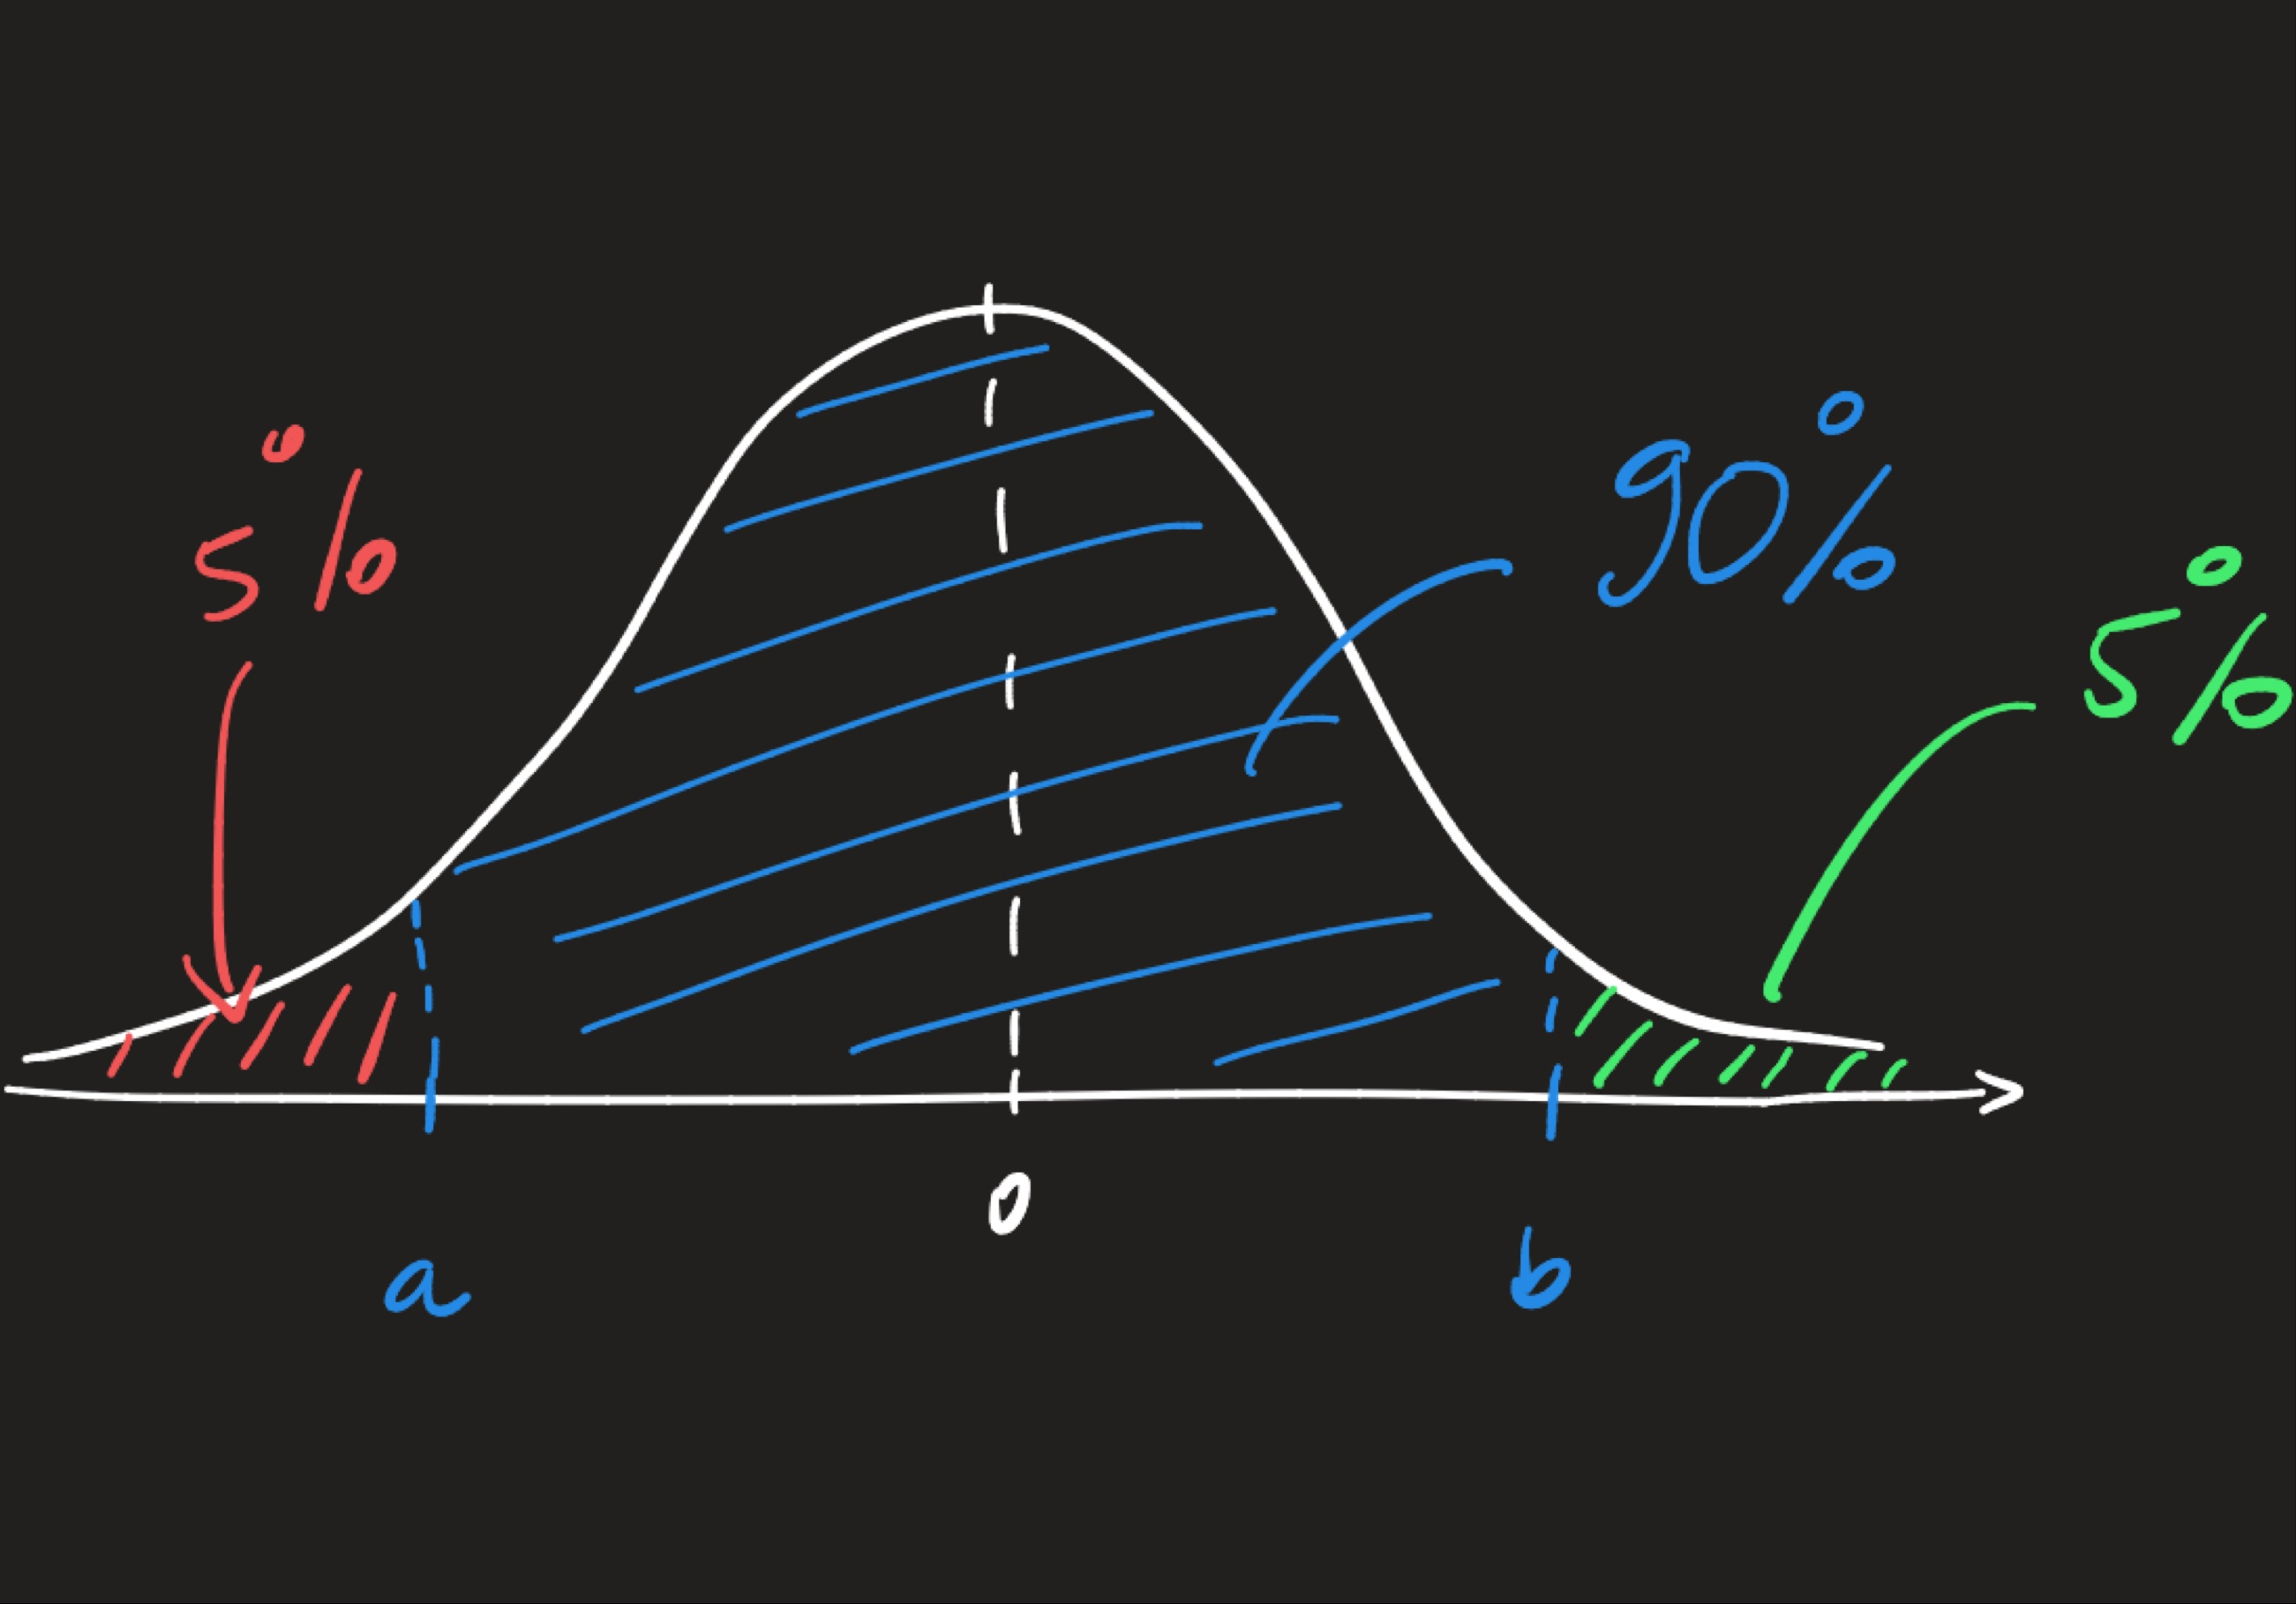

In [9]:
from IPython.display import Image
Image('GaussianRV.jpg',width=300)

The distance from the mean to $a$ is the same as the distance from the mean to $b$. Thus we really only need to find one of these values in order to know both. Leveraging the Q-function table, I will compute the survival function of $X$ at $b$, that is, $P(X\geq b) = \int_b^{\infty} e^{-t^2/2}dt$. Recall that continuous random variables have 0 probability at any particular value, $P(X=b)=0$, thus, we can write $P(X>b)=P(X\geq b)$.

From the information given, we want to find $b$ such that $P(X>b) = P(X\geq b)=0.05 \iff Q(b) = 0.05 \iff b = Q^{-1}(0.05) \approx 1.65$. By symmetry, $a=-1.65$.

Let's check using ```scipy``` functions.

In [10]:
import scipy.stats as stats

# Defining Gaussian Distrubution with mean 0 and variance 1
X = stats.norm(loc=0,scale=np.sqrt(1)) #scale is the standard deviation

# Inverse of Survival function at 0.05
a = X.ppf(0.05)
b = X.isf(0.05)
print("[a,b] = [",a,", ",b,"]")

# Check if P(-1.65 <= X <= 1.65 ) = P(X>a) - P(X>b)
print("P(X is in [a,b])=",X.sf(a) - X.sf(b))

[a,b] = [ -1.6448536269514729 ,  1.6448536269514729 ]
P(X is in [a,b])= 0.9000000000000001


---